# Multilayer Perceptron (MLP)
# **Assignment 1**
### 10 Points

---



This lab will help you understand the concept of implementing an MLP using backpropagation algorithm. You are to use PyTorch.

1. Prepare the MNIST dataset. [1 point]

    1.1 Download the training set and test set from `torchvision.datasets`
    
    1.2 Set a batch size and push the training set and test set to dataloaders.
   
2. Compute the basic statistics of the training set that includes shape, min, max, mean, variance. You can use either `torch` or `numpy`. [1 point]

3. Prepare model.

    3.1 Define your own MLP network class from `nn.Module`. [1 point]
    
    3.2 Define your optimizer and loss function. [1 point]

4. Write a function that can train the model on training set and output the performance of the model on testing set. [4 points]

    4.1 The function should be able to train the model for N epochs and validate the model on the test set after each epoch.  
    4.2 The function should print the loss and accuracy on the training set and test set after each epoch.
    
    4.3 The function should store and return lists containing the loss and accuracy history on the training set and test set, so we can print the plot of accuracy and loss. 

5. Train the model for N epochs (N is any integer chosen by you) and print the loss and accuracy for each epoch and for both training set and test set. [1 point]

6. Visualize the accuracy and loss with respect to each epoch [1 point]
    
    6.1 One plot that contains accuracy curves for training set and testing set.    
    6.2 One plot that contains loss curves for both sets.

Important Reference: To be able to understand and code Deep Learning Models that are easy and ready for production, one should seriously refer to the documentation and tutorial of PyTorch (https://pytorch.org/tutorials/).

# MNIST Images - Our best friend!

The MNIST dataset is a large database of handwritten digits that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning. 

It consists of 60,000 training images and 10,000 testing images.

Original source of MNIST Dataset: (http://yann.lecun.com/exdb/mnist/). The link is just for reference, you don't need to download anything from the link.

![alt text](https://cdn-images-1.medium.com/max/1200/1*9Mjoc_J0JR294YwHGXwCeg.jpeg)

## Necessary libraries

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data.dataloader as dataloader
import torch.optim as optim

from torch.utils.data import TensorDataset
from torchvision import transforms
from torchvision.datasets import MNIST

import matplotlib.pyplot as plt
import time

## Download the MNIST train and test set [1 point]
Using the torch.utils.data DataLoader, we shuffle the data and set the batch size to be 256. It is very important for everyone to focus on how the dataloader works. Please refer to the documentation.

In [3]:
batch_size = 256

transform = transforms.Compose([transforms.ToTensor()])

train = MNIST(root='./data', train=True, download=True, transform=transform) # Load the training data

test = MNIST(root='./data', train=False, download=True, transform=transform) # Load the test data

train_loader = dataloader.DataLoader(train, batch_size=batch_size, shuffle=True) # Push the training data to the dataloader

test_loader = dataloader.DataLoader(test, batch_size=batch_size, shuffle=False) # Push the test data to the dataloader

cuda = torch.cuda.is_available() # Check if GPU CUDA is available

## Compute basic data statistics [1 point]
It is always important to know the shape of the data, as well as the min/max and mean/variance. Print all the values.

In [5]:
train_data = train.train_data

shape = train_data.shape
print('Train data shape: ',shape)

mean = torch.mean(train_data.data.float()).item() # Calculate the mean of the training data
print('Mean of all the pixels: ',mean)

max_value = torch.max(train_data).item() # Calculate the maximum value of the training data
print('Maximum of all the pixels: ',max_value)

min_value = torch.min(train_data).item() # Calculate the minimum value of the training data
print('Minimum of all the pixels: ',min_value)

Variance = torch.var(train_data.data.float()).item() # Calculate the variance of the training data
print('Variance of all the pixels: ',Variance)

Train data shape:  torch.Size([60000, 28, 28])
Mean of all the pixels:  33.31842041015625
Maximum of all the pixels:  255
Minimum of all the pixels:  0
Variance of all the pixels:  6172.8505859375


## Visualize a few training samples
Using the matplotlib.pyplot library, we can visualize our input data.


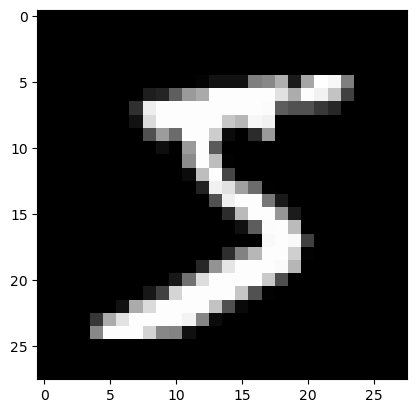

In [6]:
# Visualize a training instance with matplotlib
plt.imshow(train.train_data.cpu().numpy()[0], cmap='gray')

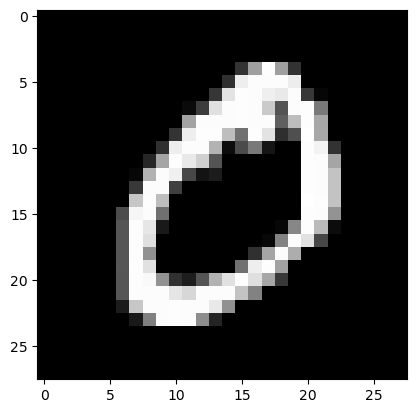

In [7]:
plt.imshow(train.train_data.cpu().numpy()[1], cmap='gray')

## Defining a Neural Network Model 



## Create the model and define the loss and optimizer [2 points]

Define your model using the torch.nn.Module class.

Create an instance of the Simple_MLP model. The input layer should contain 28*28 = 784 neurons. You may define hidden layers of different hidden dimension, and output will be the class probabilities for each of the 10 digits (0-9).

How many neurons will be there in the output layer?

This is a classification task, I recommend you use Cross Entropy Loss (It is your error function or divergence function). We define our criterion using the torch.nn.CrossEntropyLoss.

In order to train our network, we use the torch.optim.SGD optimizer. You may use the optimizer **Adam**.

In [9]:
# Please complete the code below.

# Create an instance of Simple MLP model
# Specify the activation function to use

class Simple_MLP(nn.Module):
    def __init__(self):
        super(Simple_MLP, self).__init__()
        
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# Define your Loss function
criterion = nn.CrossEntropyLoss()

# initialize and print the model
model = Simple_MLP()
print(model)

# Choose an optimizer for the model parameters (ex. optimizer = optim.Adam(model.parameters()))
optimizer = optim.Adam(model.parameters())

# device is the hardware you are using (CPU or GPU)
device = torch.device("cuda" if cuda else "cpu")

Simple_MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


## Complete the below function that will train the network [4 points]
- The function should be able to train the model for N epochs and validate the model on the test set after each epoch. 
- The function should print the loss and accuracy on the training set and test set after each epoch. 
- The function should store and return lists containing the loss and accuracy history on the training set and test set, so we can print the plot of accuracy and loss. 

In [10]:
def train_model(model, train_loader, test_loader, criterion, optimizer, n_epochs):

    # Setting up lists
    train_acc_list = []
    valid_acc_list = []
    train_loss_list = []
    valid_loss_list = []

    for epoch in range(n_epochs):
        
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output.data, 1)
            train_correct += (predicted == target).sum().item()
            
        # Validation
        model.eval()
        valid_loss = 0.0
        valid_correct = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                
                valid_loss += loss.item() * data.size(0)
                _, predicted = torch.max(output.data, 1)
                valid_correct += (predicted == target).sum().item()

        # Averages
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = 100. * train_correct / len(train_loader.dataset)
        valid_loss = valid_loss / len(test_loader.dataset)
        valid_acc = 100. * valid_correct / len(test_loader.dataset)

        # Printing values
        print(f'Epoch {epoch+1}/{n_epochs}:\n' + 
              f'\tTrain Loss: {train_loss:.4f}\n' + 
              f'\tTrain Accuracy: {train_acc:.2f}%\n' + 
              f'\tValidation Loss: {valid_loss:.4f}\n' + 
              f'\tValidation Accuracy: {valid_acc:.2f}%\n')

        # Add values to lists
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)
        valid_loss_list.append(valid_loss)
        valid_acc_list.append(valid_acc)

    return train_acc_list, valid_acc_list, train_loss_list, valid_loss_list

## Train the model for N epochs [1 point]
Train and test your network in a loop, while keeping track of the **losses and accuracy**.   

In [11]:
# Write your piece of code to run train and test the network for 10 epochs.  
n_epochs = 10
train_acc_list,valid_acc_list,train_loss_list,valid_loss_list = train_model(model, train_loader, test_loader, criterion, optimizer, n_epochs)

Epoch 1/10:
	Train Loss: 0.4503
	Train Accuracy: 88.03%
	Validation Loss: 0.2111
	Validation Accuracy: 93.86%

Epoch 2/10:
	Train Loss: 0.1823
	Train Accuracy: 94.70%
	Validation Loss: 0.1447
	Validation Accuracy: 95.70%

Epoch 3/10:
	Train Loss: 0.1247
	Train Accuracy: 96.28%
	Validation Loss: 0.1201
	Validation Accuracy: 96.28%

Epoch 4/10:
	Train Loss: 0.0936
	Train Accuracy: 97.19%
	Validation Loss: 0.0977
	Validation Accuracy: 96.97%

Epoch 5/10:
	Train Loss: 0.0724
	Train Accuracy: 97.86%
	Validation Loss: 0.0859
	Validation Accuracy: 97.37%

Epoch 6/10:
	Train Loss: 0.0555
	Train Accuracy: 98.32%
	Validation Loss: 0.0953
	Validation Accuracy: 97.12%

Epoch 7/10:
	Train Loss: 0.0477
	Train Accuracy: 98.56%
	Validation Loss: 0.0726
	Validation Accuracy: 97.80%

Epoch 8/10:
	Train Loss: 0.0343
	Train Accuracy: 99.01%
	Validation Loss: 0.0693
	Validation Accuracy: 97.80%

Epoch 9/10:
	Train Loss: 0.0274
	Train Accuracy: 99.24%
	Validation Loss: 0.0692
	Validation Accuracy: 97.90%

E

## Visualize the accuracy and loss with respect to each epoch [1 point]

Draw a graph for Training Loss percentage with respect to the number of epochs. 

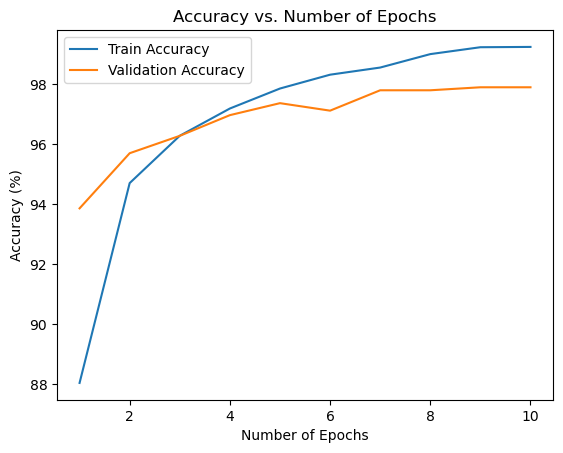

In [12]:
# Insert your code here
# plot the train accuray and validation accuracy in the same plot 

plt.plot(range(1, n_epochs+1), train_acc_list, label='Train Accuracy')
plt.plot(range(1, n_epochs+1), valid_acc_list, label='Validation Accuracy')

plt.title('Accuracy vs. Number of Epochs')
plt.xlabel('Number of Epochs')
plt.ylabel('Accuracy (%)')

plt.legend()
plt.show()

Draw a graph for Testing Loss percentage with respect to number of epochs.

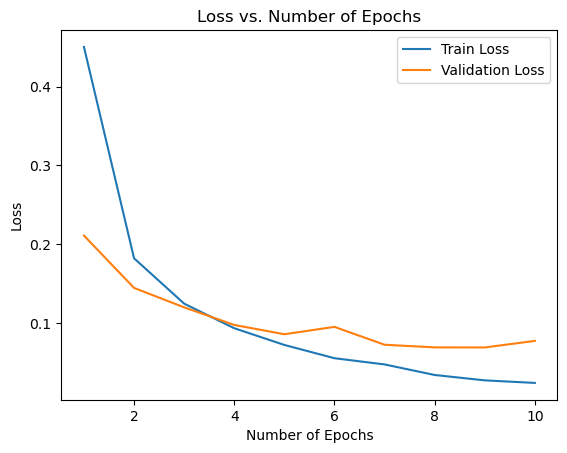

In [13]:
# plot the train loss and validation loss in the same plot 

plt.plot(range(1, n_epochs+1), train_loss_list, label='Train Loss')
plt.plot(range(1, n_epochs+1), valid_loss_list, label='Validation Loss')

plt.title('Loss vs. Number of Epochs')
plt.xlabel('Number of Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()